# Image Classification

# GitHub Link: https://github.com/lalomega/C-DAC

**Lab Assignment**: Load any image, classify it using a pre-trained model.

---

### What this notebook covers:
1. **Environment Setup** – Install and import required libraries
2. **Load & Display Image** – Load any image from disk or URL
3. **Image Classification** – Use MobileNetV2 (pre-trained on ImageNet) to classify the image


---
##  Section 1: Install Dependencies

Run this cell once to install all required packages.

In [ ]:
# Run this cell once to install required libraries
import subprocess, sys

packages = ['opencv-python', 'numpy', 'matplotlib', 'tensorflow', 'pillow', 'requests']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed successfully!')

All packages installed successfully!


---
##  Section 2: Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import os
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from io import BytesIO

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

print(f'OpenCV version  : {cv2.__version__}')
print(f'NumPy version   : {np.__version__}')
print(f'TensorFlow ver  : {tf.__version__}')
print('All libraries imported successfully!')

OpenCV version  : 4.13.0
NumPy version   : 2.0.2
TensorFlow ver  : 2.20.0
All libraries imported successfully!


---
##  Section 3: Load Your Image

**Choose ONE of the two options below:**

- **Option A** – Load from a local file path on your computer  
- **Option B** – Load from a public URL (works out of the box, no file needed)

> By default, Option B is active and uses a sample dog image. Change the URL or switch to Option A to use your own image.

# **Mount the drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Image loaded from Google Drive.
   Shape   : (350, 525, 3)  (Height x Width x Channels)
   Dtype   : uint8
   Min/Max : 0 / 255


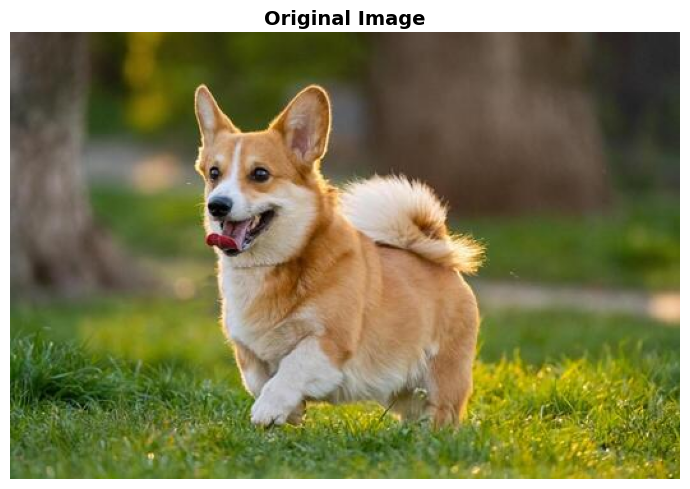

In [ ]:

# OPTION A: Load an image from Google Drive (Google Colab)
# Make sure Google Drive is mounted and provide the image file path.
# ─────────────────────────────────────────────────────────────────────────────
IMAGE_PATH = '/content/drive/MyDrive/C_DAC/img4.jpg'  # <-- change to your image path
img_bgr = cv2.imread(IMAGE_PATH)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print('Image loaded from Google Drive.')

# ─────────────────────────────────────────────────────────────────────────────
# OPTION B: Load from a URL (default – uses a sample image)
# ─────────────────────────────────────────────────────────────────────────────
# IMAGE_URL = IMAGE_URL = "https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg"
# response = requests.get(IMAGE_URL)
# pil_img = Image.open(BytesIO(response.content)).convert('RGB')
# img_rgb = np.array(pil_img)
# img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
# print('Image loaded from URL.')

# ─────────────────────────────────────────────────────────────────────────────
# Display the original image
# ─────────────────────────────────────────────────────────────────────────────
print(f'   Shape   : {img_rgb.shape}  (Height x Width x Channels)')
print(f'   Dtype   : {img_rgb.dtype}')
print(f'   Min/Max : {img_rgb.min()} / {img_rgb.max()}')

plt.figure(figsize=(7, 5))
plt.imshow(img_rgb)
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

---
##  Section 4: Image Classification with MobileNetV2

We use **MobileNetV2** — a lightweight, pre-trained convolutional neural network trained on **ImageNet** (1.2M images, 1000 classes).  
No training is required; we simply load the pre-trained weights and run inference.

**Steps:**
1. Resize the image to 224×224 (the model's expected input size)
2. Preprocess pixel values to the range expected by MobileNetV2
3. Run `model.predict()` to get class probabilities
4. Decode the top-5 predictions to human-readable labels

In [ ]:
# Step 1: Load pre-trained MobileNetV2 model
print('Loading MobileNetV2 (pre-trained on ImageNet)...')
model = MobileNetV2(weights='imagenet')
print('Model loaded!')
print(f'   Parameters : {model.count_params():,}')

# Step 2: Preprocess image for MobileNetV2
IMG_SIZE = (224, 224)

img_resized = cv2.resize(img_rgb, IMG_SIZE)          # Resize to 224×224
img_array   = img_resized.astype(np.float32)         # Convert to float
img_batch   = np.expand_dims(img_array, axis=0)      # Add batch dimension → (1,224,224,3)
img_pre     = preprocess_input(img_batch)            # Scale pixels to [-1, 1]

#  Step 3: Predict
print('\n Running classification...')
predictions = model.predict(img_pre, verbose=0)

#  Step 4: Decode top-5 predictions
top5 = decode_predictions(predictions, top=5)[0]

print('\n Top-5 Predictions:')
print(f'{"Rank":<6} {"Label":<30} {"Confidence":>12}')
print('─' * 50)
for rank, (imagenet_id, label, prob) in enumerate(top5, 1):
    bar = '|||' * int(prob * 30)
    print(f'{rank:<6} {label:<30} {prob*100:>10.2f}%  {bar}')

# Store top prediction for later use
top_label = top5[0][1].replace('_', ' ').title()
top_conf  = top5[0][2] * 100

Loading MobileNetV2 (pre-trained on ImageNet)...
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model loaded!
   Parameters : 3,538,984

 Running classification...
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 Top-5 Predictions:
Rank   Label                            Confidence
──────────────────────────────────────────────────
1      Pembroke                            53.57%  ||||||||||||||||||||||||||||||||||||||||||||||||
2      Cardigan                            15.59%  ||||||||||||
3      Eskimo_dog                           1.51%  
4      malamute                             0.79%  
5      basenji                              0.67%  


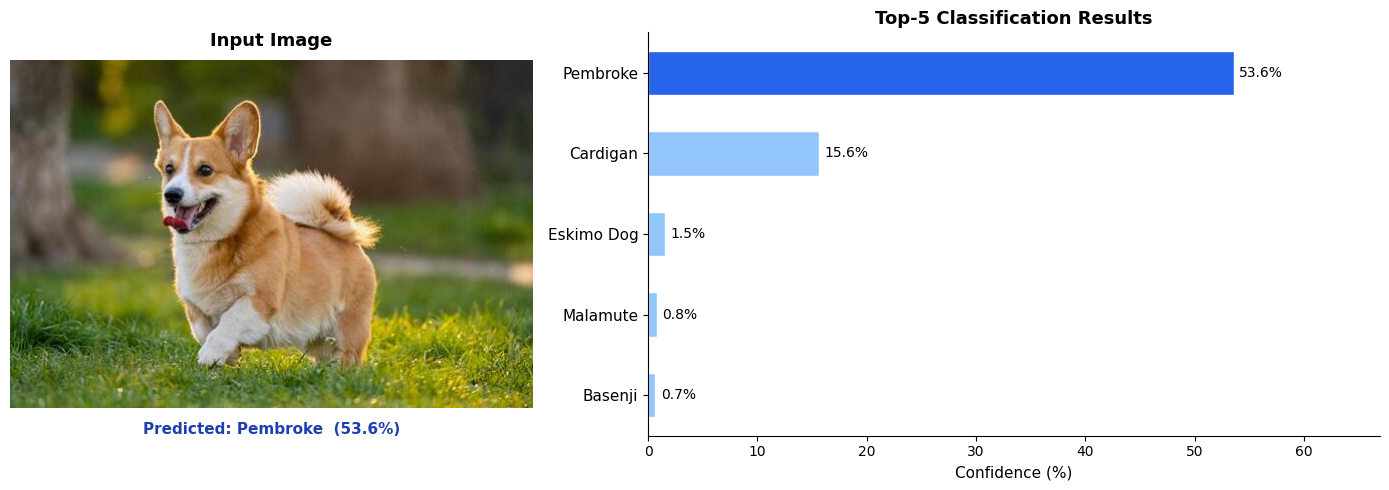

Saved: classification_results.png


In [ ]:
#  Visualize top-5 predictions as a horizontal bar chart
labels = [r[1].replace('_', ' ').title() for r in top5]
scores = [r[2] * 100 for r in top5]
colors = ['#2563EB' if i == 0 else '#93C5FD' for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.4]})

# Left: original image with top prediction overlaid
axes[0].imshow(img_rgb)
axes[0].set_title('Input Image', fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')
axes[0].text(0.5, -0.04,
             f'Predicted: {top_label}  ({top_conf:.1f}%)',
             transform=axes[0].transAxes,
             ha='center', va='top', fontsize=11,
             color='#1e40af', fontweight='bold')

# Right: horizontal bar chart of top-5
bars = axes[1].barh(range(5), scores[::-1], color=colors[::-1], height=0.55, edgecolor='white')
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(labels[::-1], fontsize=11)
axes[1].set_xlabel('Confidence (%)', fontsize=11)
axes[1].set_title('Top-5 Classification Results', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, max(scores) * 1.25)
axes[1].spines[['top', 'right']].set_visible(False)

for bar, score in zip(bars, scores[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{score:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: classification_results.png')